# Mini Project 1 Image Classification
## Step 2: ResNet-18 (Pretrained + Fine-tuned)

**Strategy**: Transfer learning: load ImageNet-pretrained ResNet-18, replace the final FC layer with a 101-class head, then fine-tune the full network.

**Ablation studies**:
- Image size: 64×64 vs 128×128
- Augmentation: with vs without

In [3]:
# ── Imports
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_recall_fscore_support
)

# ── Reproducibility 
SEED = 261
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# CUDA if available
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

Using device: mps


In [4]:
# ── Load data from Step 1
with open("shared_data.pkl", "rb") as f:
    data = pickle.load(f)

train_paths          = data["train_paths"]
train_labels         = data["train_labels"]
val_paths            = data["val_paths"]
val_labels           = data["val_labels"]
test_paths           = data["test_paths"]
test_labels          = data["test_labels"]
class_names          = data["class_names"]
class_weights_tensor = data["class_weights_tensor"]

NUM_CLASSES = len(class_names)
print(f"Classes: {NUM_CLASSES} | Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Classes: 101 | Train: 6073 | Val: 1302 | Test: 1302


In [5]:
# ── Configuration
EPOCHS      = 50
BATCH_SIZE  = 32
NUM_WORKERS = 0
LR          = 1e-4    # Adam learning rate
WEIGHT_DECAY= 1e-4    # L2 regularization

# Ablation configs — we'll loop over these
ABLATION_CONFIGS = [
    {"name": "224_aug",    "img_size": 224, "augment": True},   # baseline
    {"name": "128_aug",    "img_size": 128, "augment": True},   # ablation: image size (128)
    {"name": "64_aug",     "img_size": 64,  "augment": True},   # ablation: image size (64)
    {"name": "224_no_aug", "img_size": 224, "augment": False},  # ablation: no augmentation
]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [6]:
# ── Dataset class (same as Step 1)
class Caltech101Dataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")  # handle greyscale/RGBA
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


def get_transforms(img_size, augment):
    """Return train and eval transforms for a given image size and augment flag."""
    base = [
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
    aug = [
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
        transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
    train_tf = transforms.Compose(aug if augment else base)
    eval_tf  = transforms.Compose(base)  # eval is always deterministic
    return train_tf, eval_tf


def get_loaders(img_size, augment):
    """Build DataLoaders for a given ablation config."""
    train_tf, eval_tf = get_transforms(img_size, augment)
    train_ds = Caltech101Dataset(train_paths, train_labels, transform=train_tf)
    val_ds   = Caltech101Dataset(val_paths,   val_labels,   transform=eval_tf)
    test_ds  = Caltech101Dataset(test_paths,  test_labels,  transform=eval_tf)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=False)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)
    test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)
    return train_dl, val_dl, test_dl

In [7]:
# ── Model builder
def build_resnet18(num_classes):
    """
    Load ImageNet-pretrained ResNet-18 and replace the final FC layer.
    All layers are unfrozen — we fine-tune the full network (transfer learning).
    """
    # weights=DEFAULT loads the best available pretrained weights
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Replace the classifier head: 512 → num_classes
    # ResNet-18's final layer is model.fc (512 input features)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),              # dropout before final layer for regularization
        nn.Linear(in_features, num_classes)
    )
    return model

In [8]:
# ── Training and validation loop
def train_one_epoch(model, loader, criterion, optimizer):
    """Single training epoch — returns avg loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Validation/test evaluation — returns avg loss and accuracy."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def train_model(config):
    """
    Full training pipeline for one ablation config.
    Returns the best model and training history.
    """
    print(f"\n{'='*60}")
    print(f"Config: {config['name']} | img_size={config['img_size']} | augment={config['augment']}")
    print(f"{'='*60}")

    train_dl, val_dl, test_dl = get_loaders(config["img_size"], config["augment"])

    model = build_resnet18(NUM_CLASSES).to(DEVICE)

    # Class-weighted loss to handle imbalance; move weights to device
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))

    # Adam optimizer with weight decay (L2 regularization)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # Cosine annealing: smoothly decays LR from LR to 0 over all epochs
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc, best_model_state = 0.0, None

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_dl, criterion, optimizer)
        val_loss,   val_acc   = evaluate(model, val_dl, criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # Save best model checkpoint based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{EPOCHS} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
                  f"Time: {time.time()-t0:.1f}s")

    print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

    # Reload best weights before returning
    model.load_state_dict(best_model_state)
    torch.save(best_model_state, f"resnet18_{config['name']}_best.pth")
    print(f"Model saved: resnet18_{config['name']}_best.pth")

    return model, history, train_dl, val_dl, test_dl

In [9]:
# ── Run all ablation configs
# Stores results keyed by config name for later comparison
all_results = {}

for config in ABLATION_CONFIGS:
    model, history, train_dl, val_dl, test_dl = train_model(config)
    all_results[config["name"]] = {
        "model"  : model,
        "history": history,
        "loaders": (train_dl, val_dl, test_dl),
    }


Config: 224_aug | img_size=224 | augment=True
Epoch   1/50 | Train Loss: 3.1566 Acc: 0.4546 | Val Loss: 1.2928 Acc: 0.8756 | Time: 68.4s
Epoch   5/50 | Train Loss: 0.2622 Acc: 0.9674 | Val Loss: 0.3070 Acc: 0.9539 | Time: 68.4s
Epoch  10/50 | Train Loss: 0.0752 Acc: 0.9911 | Val Loss: 0.2352 Acc: 0.9601 | Time: 69.1s
Epoch  15/50 | Train Loss: 0.0441 Acc: 0.9954 | Val Loss: 0.2484 Acc: 0.9608 | Time: 68.3s
Epoch  20/50 | Train Loss: 0.0448 Acc: 0.9942 | Val Loss: 0.2473 Acc: 0.9585 | Time: 68.9s
Epoch  25/50 | Train Loss: 0.0152 Acc: 0.9979 | Val Loss: 0.2350 Acc: 0.9601 | Time: 68.6s
Epoch  30/50 | Train Loss: 0.0086 Acc: 0.9990 | Val Loss: 0.2455 Acc: 0.9601 | Time: 68.3s
Epoch  35/50 | Train Loss: 0.0049 Acc: 0.9992 | Val Loss: 0.1945 Acc: 0.9670 | Time: 68.7s
Epoch  40/50 | Train Loss: 0.0042 Acc: 0.9995 | Val Loss: 0.1902 Acc: 0.9670 | Time: 68.4s
Epoch  45/50 | Train Loss: 0.0033 Acc: 0.9993 | Val Loss: 0.1881 Acc: 0.9677 | Time: 68.3s
Epoch  50/50 | Train Loss: 0.0032 Acc: 0.99

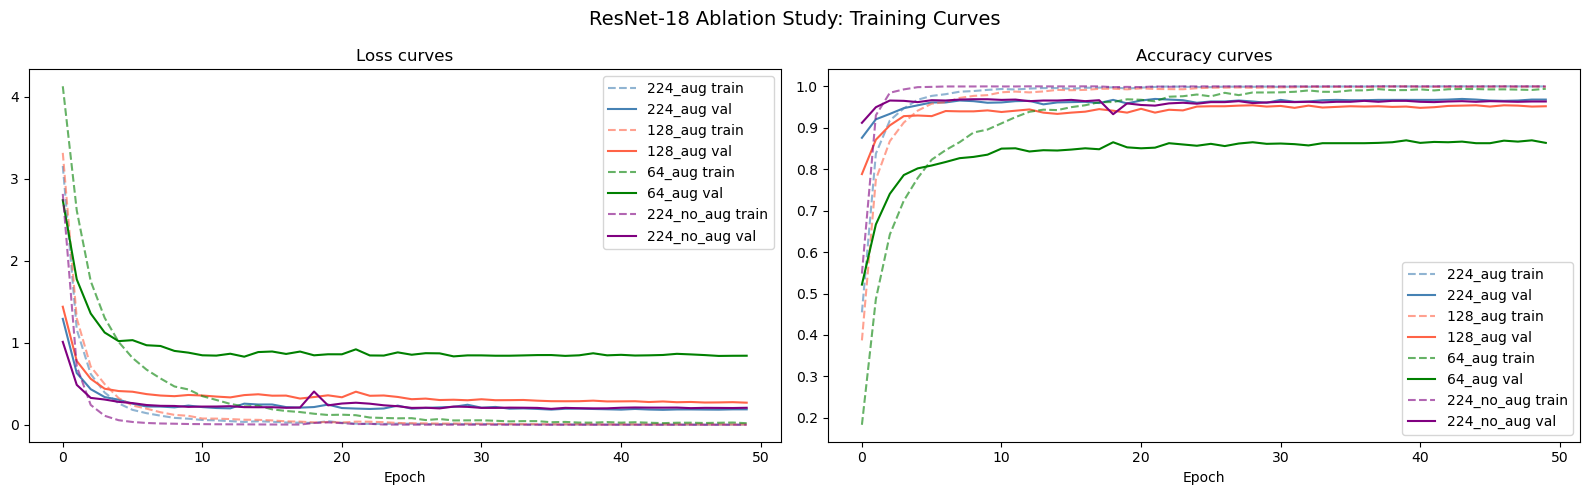

In [16]:
# ── Plot training curves for all configs
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ["steelblue", "tomato", "green", "purple"]

for i, (name, res) in enumerate(all_results.items()):
    h = res["history"]
    axes[0].plot(h["train_loss"], linestyle="--", color=colors[i], alpha=0.6, label=f"{name} train")
    axes[0].plot(h["val_loss"],   linestyle="-",  color=colors[i],            label=f"{name} val")
    axes[1].plot(h["train_acc"],  linestyle="--", color=colors[i], alpha=0.6, label=f"{name} train")
    axes[1].plot(h["val_acc"],    linestyle="-",  color=colors[i],            label=f"{name} val")

axes[0].set_title("Loss curves");  axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Accuracy curves"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.suptitle("ResNet-18 Ablation Study: Training Curves", fontsize=14)
plt.tight_layout()
plt.savefig("resnet18_training_curves.png", dpi=100, bbox_inches="tight")
plt.show()

In [18]:
# ── Evaluation helper
@torch.no_grad()
def get_predictions(model, loader):
    """Run inference on a dataloader, return all true labels and predicted labels."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()  # for top-5 accuracy
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())
        all_probs.append(probs)
    return (
        np.concatenate(all_labels),
        np.concatenate(all_preds),
        np.concatenate(all_probs)
    )


def top5_accuracy(labels, probs):
    """Compute top-5 accuracy: correct if true label is in top-5 predicted classes."""
    top5 = np.argsort(probs, axis=1)[:, -5:]  # indices of top-5 probs per sample
    correct = sum(labels[i] in top5[i] for i in range(len(labels)))
    return correct / len(labels)


def full_evaluation(name, model, test_dl):
    """Compute and print all evaluation metrics for a given config."""
    print(f"\n{'='*60}")
    print(f"Evaluation: {name}")
    print(f"{'='*60}")

    y_true, y_pred, y_probs = get_predictions(model, test_dl)

    # Overall accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"Overall Accuracy : {acc:.4f}")

    # Top-5 accuracy
    top5 = top5_accuracy(y_true, y_probs)
    print(f"Top-5 Accuracy   : {top5:.4f}")

    # Macro and weighted precision, recall, F1
    p_mac, r_mac, f_mac, _ = precision_recall_fscore_support(y_true, y_pred, average="macro",    zero_division=0)
    p_wt,  r_wt,  f_wt,  _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    print(f"Macro    — P: {p_mac:.4f}  R: {r_mac:.4f}  F1: {f_mac:.4f}")
    print(f"Weighted — P: {p_wt:.4f}  R: {r_wt:.4f}  F1: {f_wt:.4f}")

    # Per-class accuracy
    report = classification_report(y_true, y_pred, target_names=class_names,
                                   output_dict=True, zero_division=0)
    per_class_acc = {cls: report[cls]["recall"] for cls in class_names}
    worst5  = sorted(per_class_acc.items(), key=lambda x: x[1])[:5]
    best5   = sorted(per_class_acc.items(), key=lambda x: x[1], reverse=True)[:5]
    print(f"\nTop-5 best  classes: {best5}")
    print(f"Top-5 worst classes: {worst5}")

    return y_true, y_pred, {
        "acc": acc, "top5": top5,
        "macro_f1": f_mac, "weighted_f1": f_wt,
        "per_class_acc": per_class_acc
    }

In [20]:
# ── Run evaluation on all configs
eval_results = {}

for name, res in all_results.items():
    _, _, test_dl = res["loaders"]
    y_true, y_pred, metrics = full_evaluation(name, res["model"].to(DEVICE), test_dl)
    eval_results[name] = {"y_true": y_true, "y_pred": y_pred, "metrics": metrics}


Evaluation: 224_aug
Overall Accuracy : 0.9555
Top-5 Accuracy   : 0.9962
Macro    — P: 0.9417  R: 0.9314  F1: 0.9317
Weighted — P: 0.9612  R: 0.9555  F1: 0.9555

Top-5 best  classes: [('Faces', 1.0), ('Faces_easy', 1.0), ('Motorbikes', 1.0), ('accordion', 1.0), ('airplanes', 1.0)]
Top-5 worst classes: [('octopus', 0.4), ('ant', 0.6666666666666666), ('lobster', 0.6666666666666666), ('lotus', 0.7), ('beaver', 0.7142857142857143)]

Evaluation: 128_aug
Overall Accuracy : 0.9409
Top-5 Accuracy   : 0.9900
Macro    — P: 0.9225  R: 0.9092  F1: 0.9080
Weighted — P: 0.9462  R: 0.9409  F1: 0.9389

Top-5 best  classes: [('Faces_easy', 1.0), ('Leopards', 1.0), ('Motorbikes', 1.0), ('accordion', 1.0), ('airplanes', 1.0)]
Top-5 worst classes: [('octopus', 0.4), ('cougar_body', 0.42857142857142855), ('elephant', 0.5), ('lobster', 0.5), ('lotus', 0.5)]

Evaluation: 64_aug
Overall Accuracy : 0.8587
Top-5 Accuracy   : 0.9578
Macro    — P: 0.8078  R: 0.7869  F1: 0.7857
Weighted — P: 0.8644  R: 0.8587  F1:

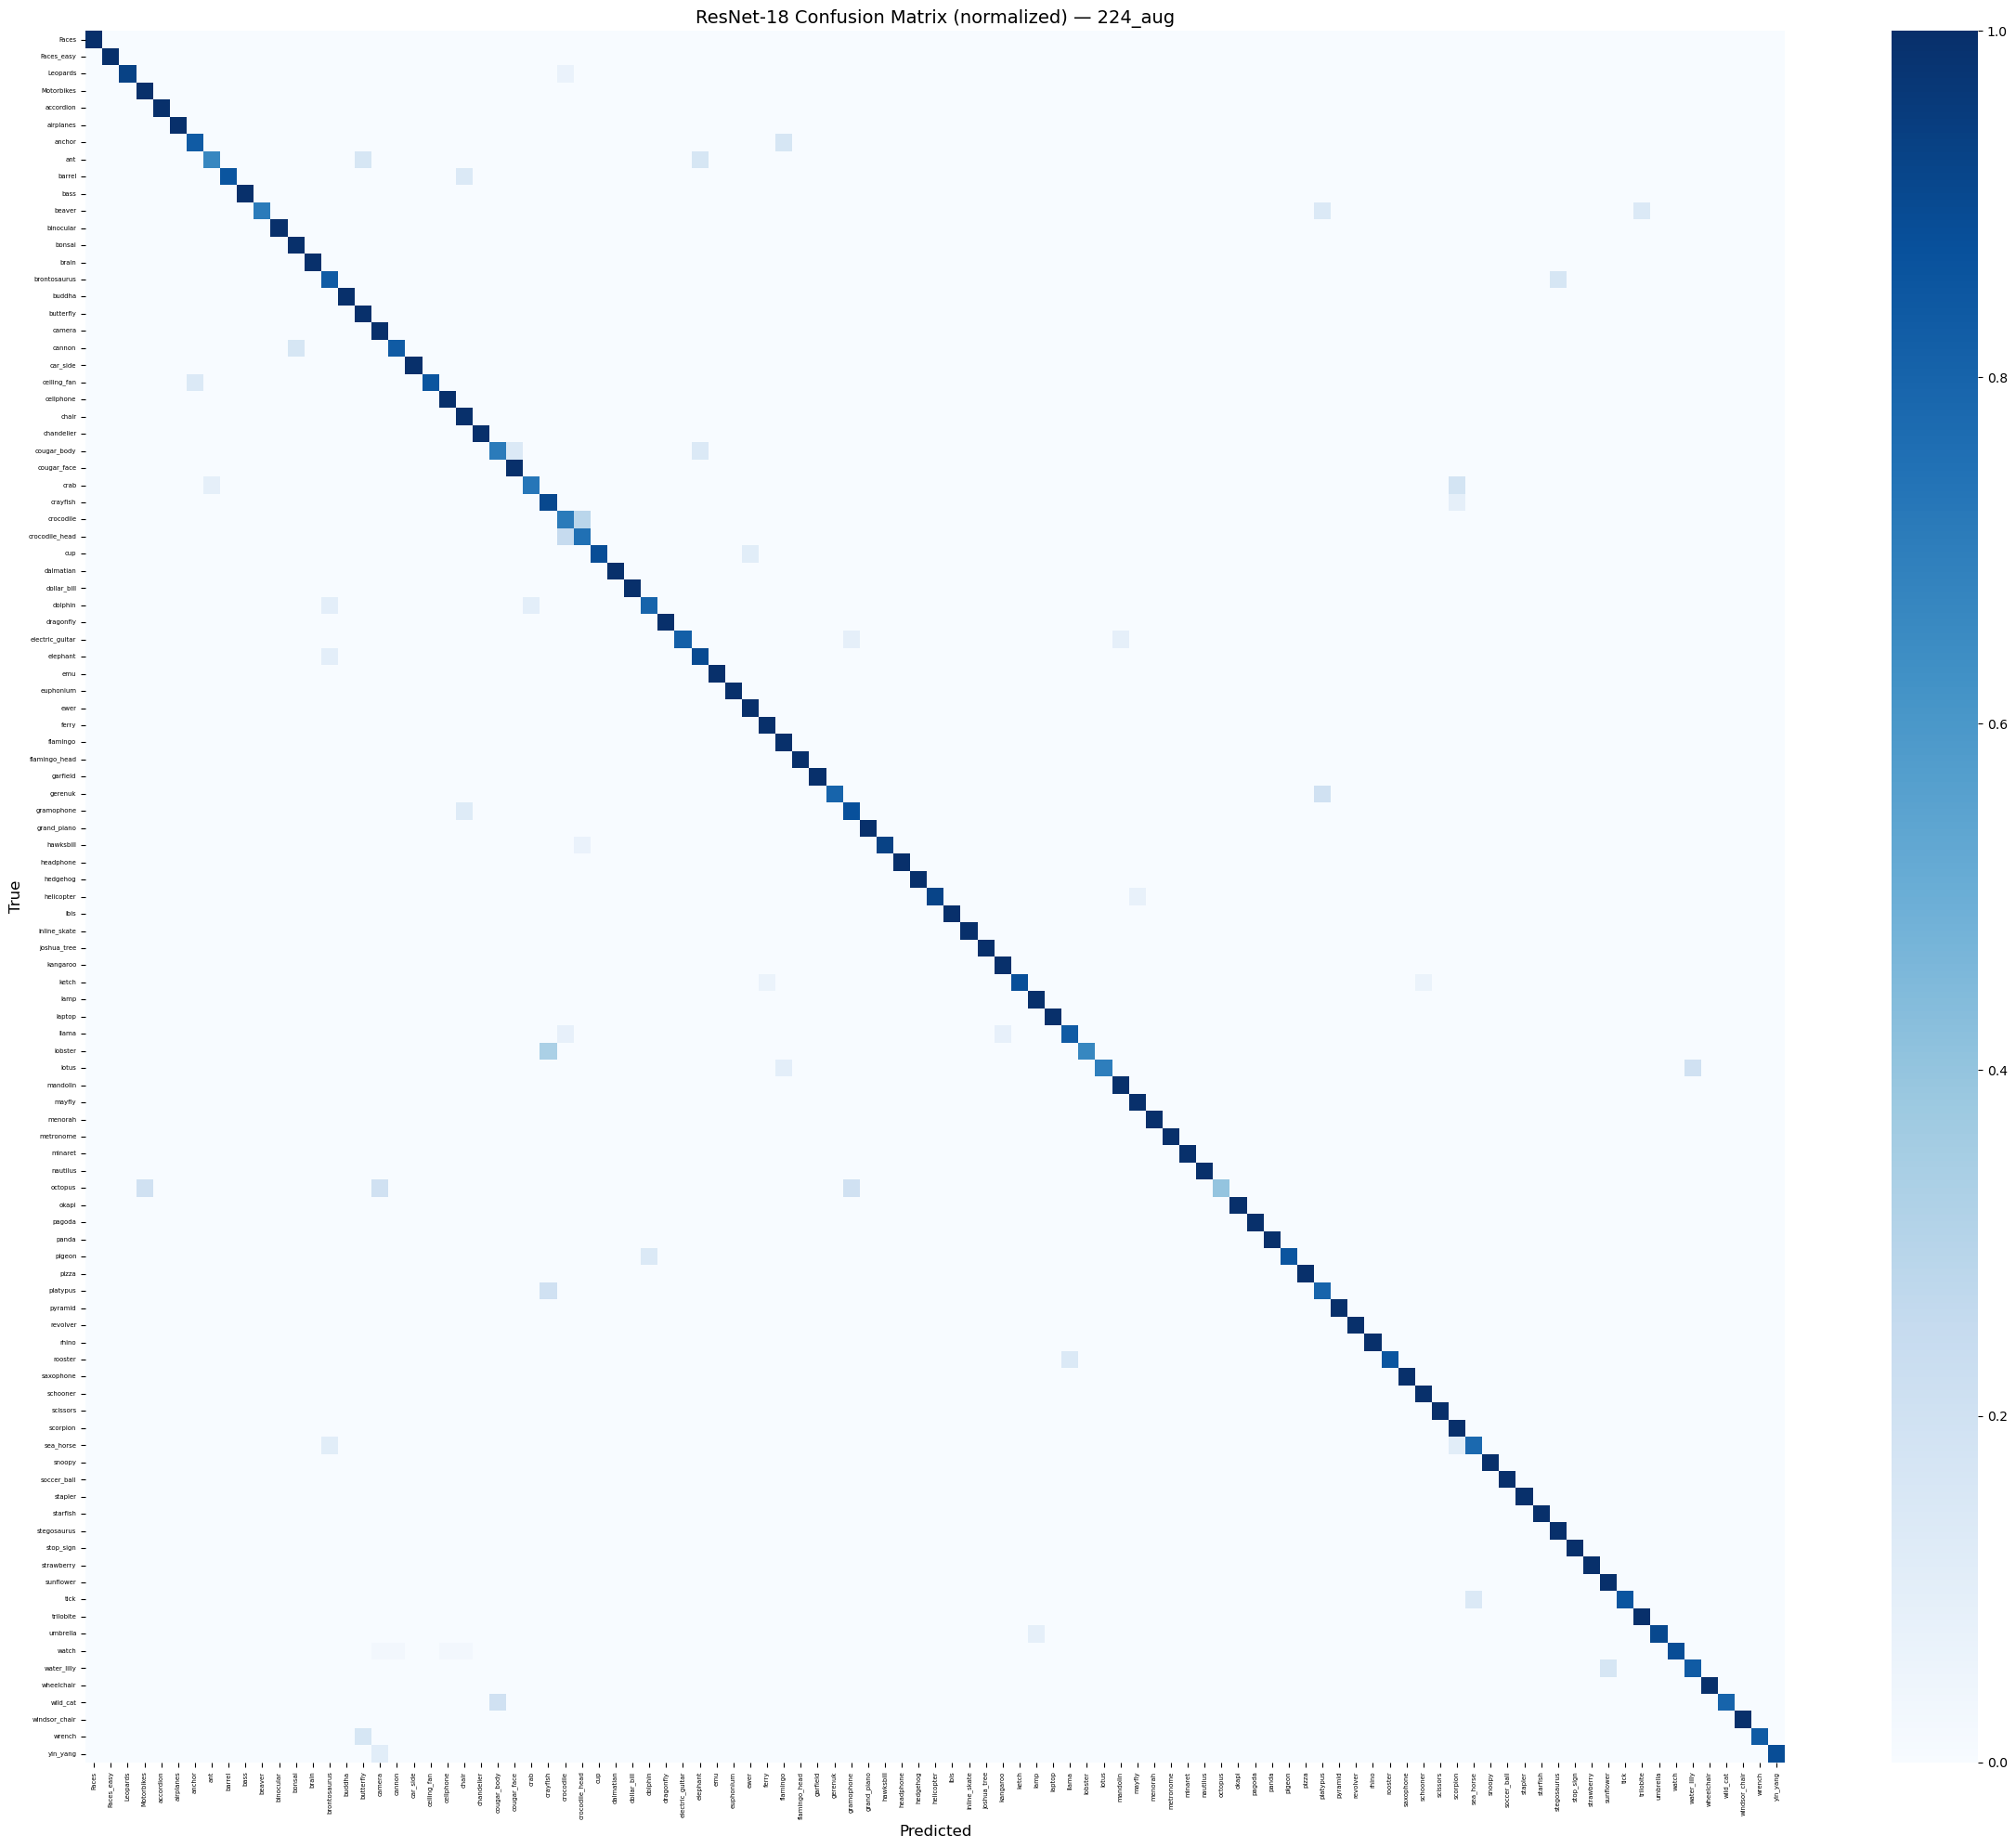

In [21]:
# ── Confusion matrix — baseline config only (101×101 is too large for all)
baseline_name = "224_aug"
y_true = eval_results[baseline_name]["y_true"]
y_pred = eval_results[baseline_name]["y_pred"]

cm = confusion_matrix(y_true, y_pred)

# Normalize by true class count for readability
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(24, 20))
sns.heatmap(cm_norm, ax=ax, cmap="Blues", xticklabels=class_names,
            yticklabels=class_names, vmin=0, vmax=1)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(f"ResNet-18 Confusion Matrix (normalized) — {baseline_name}", fontsize=14)
plt.xticks(rotation=90, fontsize=5)
plt.yticks(rotation=0,  fontsize=5)
plt.tight_layout()
plt.savefig("resnet18_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

In [22]:
# ── Ablation comparison table
import pandas as pd

rows = []
for name, res in eval_results.items():
    m = res["metrics"]
    rows.append({
        "Config"      : name,
        "Accuracy"    : f"{m['acc']:.4f}",
        "Top-5 Acc"   : f"{m['top5']:.4f}",
        "Macro F1"    : f"{m['macro_f1']:.4f}",
        "Weighted F1" : f"{m['weighted_f1']:.4f}",
    })

df = pd.DataFrame(rows)
print("\n📊 ResNet-18 Ablation Results:")
print(df.to_string(index=False))
df.to_csv("resnet18_ablation_results.csv", index=False)
print("\nSaved: resnet18_ablation_results.csv")


📊 ResNet-18 Ablation Results:
    Config Accuracy Top-5 Acc Macro F1 Weighted F1
   224_aug   0.9555    0.9962   0.9317      0.9555
   128_aug   0.9409    0.9900   0.9080      0.9389
    64_aug   0.8587    0.9578   0.7857      0.8542
224_no_aug   0.9685    0.9962   0.9482      0.9673

Saved: resnet18_ablation_results.csv


In [23]:
# ── Save evaluation results for final report
# Strip model objects (too large) — save only metrics and predictions
report_data = {
    name: {
        "y_true"  : res["y_true"],
        "y_pred"  : res["y_pred"],
        "metrics" : res["metrics"],
        "history" : all_results[name]["history"],
    }
    for name, res in eval_results.items()
}

with open("resnet18_results.pkl", "wb") as f:
    pickle.dump(report_data, f)

print("resnet18_results.pkl saved — will be used in the final report.")
print("\nShare the ablation table above and confirm before we move to EfficientNet.")

resnet18_results.pkl saved — will be used in the final report.

Share the ablation table above and confirm before we move to EfficientNet.
